# 02 Modeling - Credit Card Fraud Detection

This notebook trains and compares fraud-detection models using the cleaned and engineered dataset from `EDA.ipynb`.

Two feature versions are evaluated:

- **Version A:** includes `_ExtremeFlag` features
- **Version B:** excludes `_ExtremeFlag` features

The test set remains untouched and imbalanced. SMOTE is applied only to the training data after the train-test split.

## 1. Imports and Configuration

This section imports the modeling stack, creates output folders, and centralizes path/modeling constants.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

try:
    from imblearn.over_sampling import SMOTE
except ImportError as exc:
    raise ImportError(
        "imbalanced-learn is required for SMOTE. Install it with: pip install imbalanced-learn"
    ) from exc

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.20

DATA_PATH = Path("data/processed/creditcard_cleaned_engineered.csv")
PLOTS_DIR = Path("outputs/plots")
RESULTS_PATH = Path("outputs/model_results.csv")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

## 2. Load Processed Dataset

The modeling notebook uses the processed dataset saved by EDA: `data/processed/creditcard_cleaned_engineered.csv`.

If this file does not exist yet, rerun the final save step in `EDA.ipynb` before continuing.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {DATA_PATH}\n"
        "Run EDA.ipynb and save the cleaned engineered dataset first.\n"
        "Expected save command in EDA: df.to_csv('data/processed/creditcard_cleaned_engineered.csv', index=False)"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

print("\nClass distribution:")
display(df["Class"].value_counts())

print("\nClass distribution (%):")
display((df["Class"].value_counts(normalize=True) * 100).round(4))

Dataset loaded successfully
Shape: (283726, 45)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V7_ExtremeFlag,V8_ExtremeFlag,V23_ExtremeFlag,LogAmount,IsZeroAmount,Hour,HourOfDay,Day,HourSin,HourCos
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0,0,0,5.014760,0,0,0,0,0.0,1.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0,0,0,1.305626,0,0,0,0,0.0,1.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0,0,0,5.939276,0,0,0,0,0.0,1.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0,0,0,4.824306,0,0,0,0,0.0,1.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0,0,0,4.262539,0,0,0,0,0.0,1.0



Class distribution:


Class
0    283253
1       473
Name: count, dtype: int64


Class distribution (%):


Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64

## 3. Feature Versions

Version A keeps all engineered features, including `_ExtremeFlag` columns.

Version B removes `_ExtremeFlag` columns to test whether those explicit outlier indicators improve fraud detection.

Raw `Time`, raw `Amount`, and intermediate time columns are excluded from modeling because they were replaced by engineered features.

In [3]:
TARGET = "Class"
raw_or_intermediate_cols = ["Time", "Amount", "Hour", "HourOfDay"]
extreme_flag_cols = [col for col in df.columns if col.endswith("_ExtremeFlag")]

base_drop_cols = [TARGET] + [col for col in raw_or_intermediate_cols if col in df.columns]

feature_cols_A = [col for col in df.columns if col not in base_drop_cols]
feature_cols_B = [col for col in feature_cols_A if col not in extreme_flag_cols]

feature_versions = {
    "Version A - With ExtremeFlags": feature_cols_A,
    "Version B - Without ExtremeFlags": feature_cols_B,
}

print(f"ExtremeFlag columns found: {len(extreme_flag_cols)}")
print(extreme_flag_cols)

for version_name, cols in feature_versions.items():
    print(f"\n{version_name}: {len(cols)} features")
    print(cols)

ExtremeFlag columns found: 7
['V1_ExtremeFlag', 'V2_ExtremeFlag', 'V3_ExtremeFlag', 'V5_ExtremeFlag', 'V7_ExtremeFlag', 'V8_ExtremeFlag', 'V23_ExtremeFlag']

Version A - With ExtremeFlags: 40 features
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V1_ExtremeFlag', 'V2_ExtremeFlag', 'V3_ExtremeFlag', 'V5_ExtremeFlag', 'V7_ExtremeFlag', 'V8_ExtremeFlag', 'V23_ExtremeFlag', 'LogAmount', 'IsZeroAmount', 'Day', 'HourSin', 'HourCos']

Version B - Without ExtremeFlags: 33 features
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'LogAmount', 'IsZeroAmount', 'Day', 'HourSin', 'HourCos']


## 4. Modeling Helpers

The helper functions below keep the evaluation consistent across versions and models.

Important safeguards:

- Train-test split uses `stratify=y`
- Test data is never resampled
- SMOTE is applied only to training data
- Logistic Regression uses scaling because it is scale-sensitive
- Tree models are trained on unscaled features

In [4]:
def get_models():
    return {
        "Logistic Regression": LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE,
            n_jobs=None,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=250,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "HistGradientBoosting": HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            random_state=RANDOM_STATE,
        ),
    }


def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    raise AttributeError("Model does not expose predict_proba or decision_function.")


def evaluate_predictions(y_true, y_pred, y_score):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc_avg_precision": average_precision_score(y_true, y_score),
    }


def save_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    path = PLOTS_DIR / filename
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path


def safe_name(text):
    return (
        text.lower()
        .replace(" - ", "_")
        .replace(" ", "_")
        .replace("/", "_")
    )

## 5. Train and Evaluate Models

Each feature version is split independently with stratification. The same random seed is used so the comparison stays fair.

SMOTE is fitted only on `X_train`, never on the full dataset and never on `X_test`.


Version A - With ExtremeFlags


Train shape: (226980, 40)  Test shape: (56746, 40)
Train fraud rate: 0.1665 %
Test fraud rate:  0.1674 %

Training: Logistic Regression


After SMOTE: (453204, 40)  Fraud rate: 50.0 %


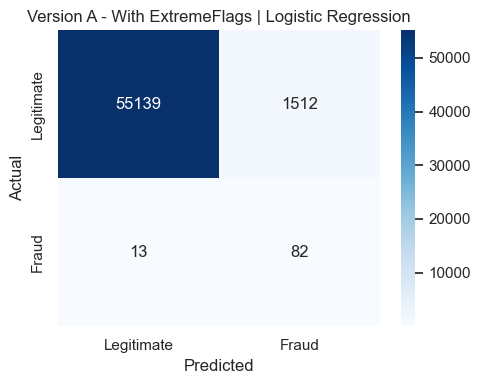


Training: Random Forest


After SMOTE: (453204, 40)  Fraud rate: 50.0 %


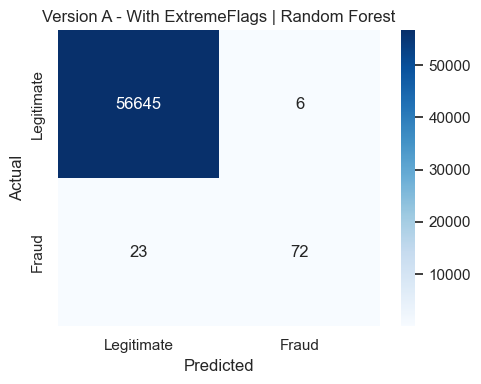


Training: HistGradientBoosting


After SMOTE: (453204, 40)  Fraud rate: 50.0 %


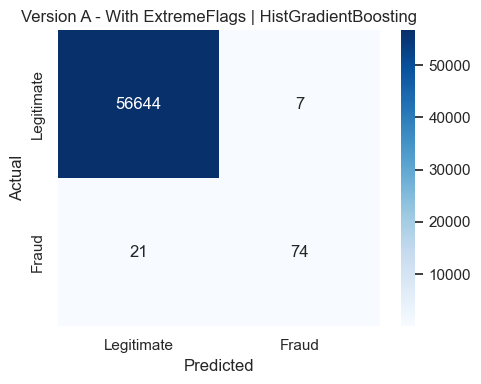


Version B - Without ExtremeFlags


Train shape: (226980, 33)  Test shape: (56746, 33)
Train fraud rate: 0.1665 %
Test fraud rate:  0.1674 %

Training: Logistic Regression


After SMOTE: (453204, 33)  Fraud rate: 50.0 %


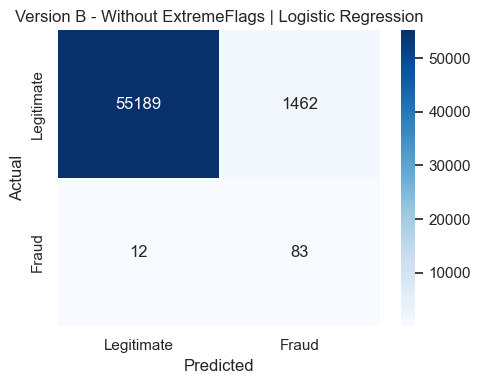


Training: Random Forest


After SMOTE: (453204, 33)  Fraud rate: 50.0 %


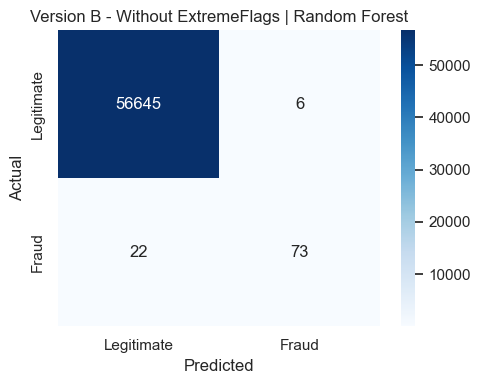


Training: HistGradientBoosting


After SMOTE: (453204, 33)  Fraud rate: 50.0 %


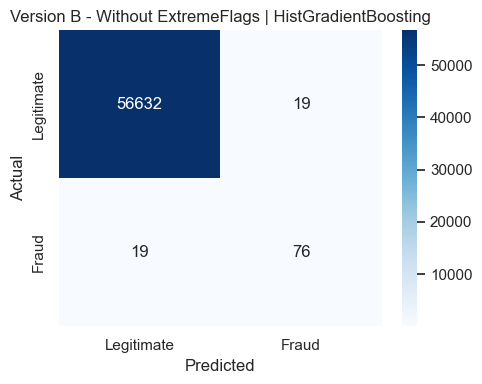


Saved model results to: outputs\model_results.csv


,version,model,threshold,n_features,train_rows_original,train_rows_after_smote,test_rows,precision,recall,f1,roc_auc,pr_auc_avg_precision
4,Version B - Without ExtremeFlags,Random Forest,0.5,33,226980,453204,56746,0.924051,0.768421,0.839080,0.986168,0.816021
1,Version A - With ExtremeFlags,Random Forest,0.5,40,226980,453204,56746,0.923077,0.757895,0.832370,0.971411,0.810163
2,Version A - With ExtremeFlags,HistGradientBoosting,0.5,40,226980,453204,56746,0.913580,0.778947,0.840909,0.964643,0.809738
5,Version B - Without ExtremeFlags,HistGradientBoosting,0.5,33,226980,453204,56746,0.800000,0.800000,0.800000,0.960269,0.807664
3,Version B - Without ExtremeFlags,Logistic Regression,0.5,33,226980,453204,56746,0.053722,0.873684,0.101220,0.964421,0.686929
0,Version A - With ExtremeFlags,Logistic Regression,0.5,40,226980,453204,56746,0.051443,0.863158,0.097099,0.961999,0.634879


In [5]:
all_results = []
trained_artifacts = {}

for version_name, feature_cols in feature_versions.items():
    print("\n" + "=" * 90)
    print(version_name)
    print("=" * 90)

    X = df[feature_cols]
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
    print("Train fraud rate:", round(y_train.mean() * 100, 4), "%")
    print("Test fraud rate: ", round(y_test.mean() * 100, 4), "%")

    models = get_models()

    for model_name, model in models.items():
        print(f"\nTraining: {model_name}")

        if model_name == "Logistic Regression":
            scaler = StandardScaler()
            X_train_model = scaler.fit_transform(X_train)
            X_test_model = scaler.transform(X_test)

            smote = SMOTE(random_state=RANDOM_STATE)
            X_train_resampled, y_train_resampled = smote.fit_resample(X_train_model, y_train)
        else:
            scaler = None
            smote = SMOTE(random_state=RANDOM_STATE)
            X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
            X_test_model = X_test

        print("After SMOTE:", X_train_resampled.shape, " Fraud rate:", round(y_train_resampled.mean() * 100, 2), "%")

        model.fit(X_train_resampled, y_train_resampled)

        y_score = get_positive_scores(model, X_test_model)
        y_pred = (y_score >= 0.50).astype(int)

        metrics = evaluate_predictions(y_test, y_pred, y_score)
        row = {
            "version": version_name,
            "model": model_name,
            "threshold": 0.50,
            "n_features": len(feature_cols),
            "train_rows_original": len(X_train),
            "train_rows_after_smote": len(X_train_resampled),
            "test_rows": len(X_test),
            **metrics,
        }
        all_results.append(row)

        artifact_key = (version_name, model_name)
        trained_artifacts[artifact_key] = {
            "model": model,
            "scaler": scaler,
            "feature_cols": feature_cols,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "X_test_model": X_test_model,
            "y_score": y_score,
            "y_pred": y_pred,
        }

        plot_file = f"confusion_matrix_{safe_name(version_name)}_{safe_name(model_name)}.png"
        save_confusion_matrix(
            y_test,
            y_pred,
            f"{version_name} | {model_name}",
            plot_file,
        )

results_df = pd.DataFrame(all_results).sort_values(
    by=["pr_auc_avg_precision", "f1", "recall"],
    ascending=False,
)

results_df.to_csv(RESULTS_PATH, index=False)
print(f"\nSaved model results to: {RESULTS_PATH}")
display(results_df)

## 6. ROC and Precision-Recall Curves

ROC-AUC is useful, but on highly imbalanced fraud data, Precision-Recall AUC is usually more informative because it focuses on the minority fraud class.

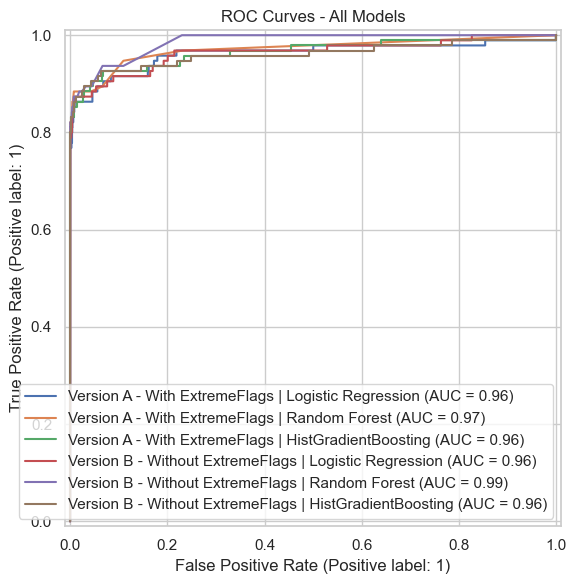

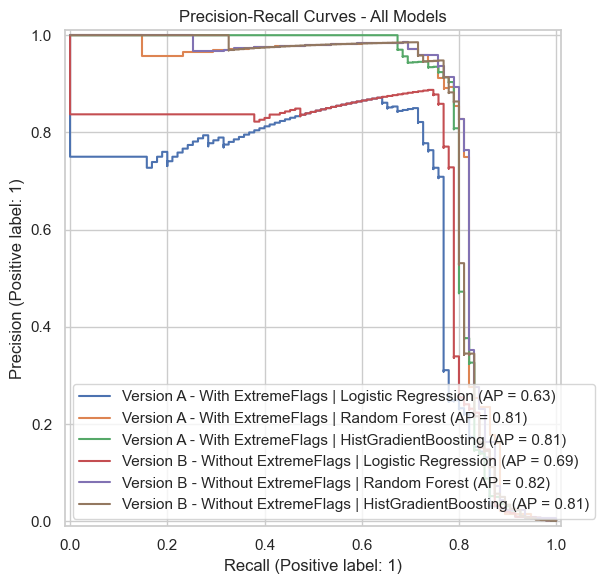

Saved:
outputs\plots\roc_curves_all_models.png
outputs\plots\precision_recall_curves_all_models.png


In [6]:
plt.figure(figsize=(9, 6))
for (version_name, model_name), artifact in trained_artifacts.items():
    RocCurveDisplay.from_predictions(
        artifact["y_test"],
        artifact["y_score"],
        name=f"{version_name} | {model_name}",
        ax=plt.gca(),
    )
plt.title("ROC Curves - All Models")
plt.tight_layout()
roc_path = PLOTS_DIR / "roc_curves_all_models.png"
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 6))
for (version_name, model_name), artifact in trained_artifacts.items():
    PrecisionRecallDisplay.from_predictions(
        artifact["y_test"],
        artifact["y_score"],
        name=f"{version_name} | {model_name}",
        ax=plt.gca(),
    )
plt.title("Precision-Recall Curves - All Models")
plt.tight_layout()
pr_path = PLOTS_DIR / "precision_recall_curves_all_models.png"
plt.savefig(pr_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:")
print(roc_path)
print(pr_path)

## 7. Threshold Tuning for the Best Model

The best model is selected by Average Precision / PR-AUC. Threshold tuning is done on a validation split carved from the training data, not on the final test set.

After finding the best validation threshold, the model is retrained on the full training data and evaluated once on the untouched imbalanced test set.

Best model by PR-AUC:


,version,model,threshold,n_features,train_rows_original,train_rows_after_smote,test_rows,precision,recall,f1,roc_auc,pr_auc_avg_precision
4,Version B - Without ExtremeFlags,Random Forest,0.5,33,226980,453204,56746,0.924051,0.768421,0.83908,0.986168,0.816021


Best validation threshold: 0.63


,threshold,precision,recall,f1
62,0.63,0.969697,0.842105,0.901408


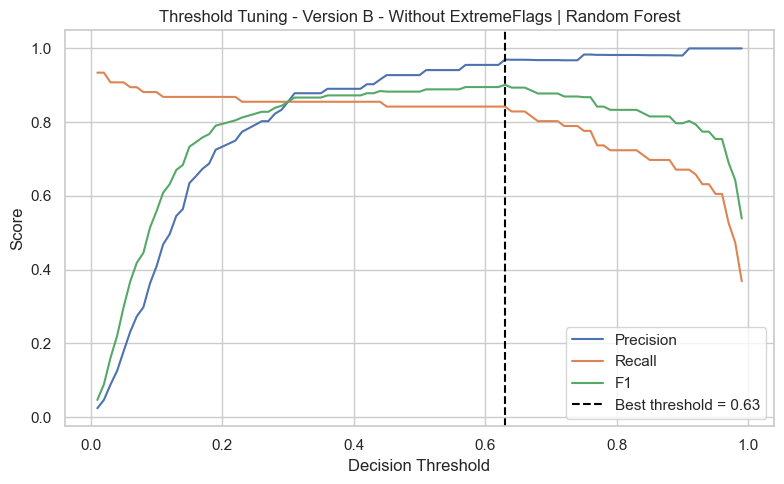


Tuned-threshold performance on untouched test set:


,version,model,threshold,n_features,train_rows_original,train_rows_after_smote,test_rows,precision,recall,f1,roc_auc,pr_auc_avg_precision
0,Version B - Without ExtremeFlags,Random Forest,0.63,33,226980,453204,56746,0.958333,0.726316,0.826347,0.986168,0.816021



Classification report:
              precision    recall  f1-score   support

           0     0.9995    0.9999    0.9997     56651
           1     0.9583    0.7263    0.8263        95

    accuracy                         0.9995     56746
   macro avg     0.9789    0.8631    0.9130     56746
weighted avg     0.9995    0.9995    0.9995     56746



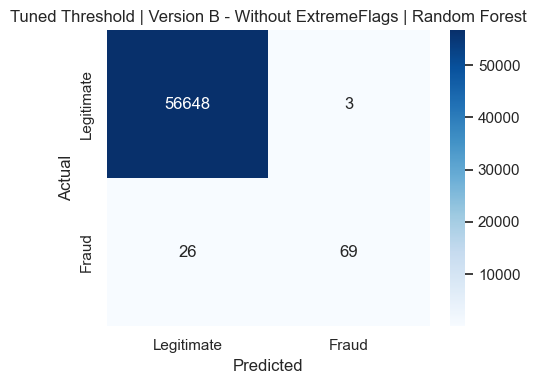

Updated model results saved to: outputs\model_results.csv


,version,model,threshold,n_features,train_rows_original,train_rows_after_smote,test_rows,precision,recall,f1,roc_auc,pr_auc_avg_precision
0,Version B - Without ExtremeFlags,Random Forest,0.50,33,226980,453204,56746,0.924051,0.768421,0.839080,0.986168,0.816021
6,Version B - Without ExtremeFlags,Random Forest - Tuned Threshold,0.63,33,226980,453204,56746,0.958333,0.726316,0.826347,0.986168,0.816021
1,Version A - With ExtremeFlags,Random Forest,0.50,40,226980,453204,56746,0.923077,0.757895,0.832370,0.971411,0.810163
2,Version A - With ExtremeFlags,HistGradientBoosting,0.50,40,226980,453204,56746,0.913580,0.778947,0.840909,0.964643,0.809738
3,Version B - Without ExtremeFlags,HistGradientBoosting,0.50,33,226980,453204,56746,0.800000,0.800000,0.800000,0.960269,0.807664
4,Version B - Without ExtremeFlags,Logistic Regression,0.50,33,226980,453204,56746,0.053722,0.873684,0.101220,0.964421,0.686929
5,Version A - With ExtremeFlags,Logistic Regression,0.50,40,226980,453204,56746,0.051443,0.863158,0.097099,0.961999,0.634879


In [7]:
best_row = results_df.iloc[0]
best_version = best_row["version"]
best_model_name = best_row["model"]
best_feature_cols = feature_versions[best_version]

print("Best model by PR-AUC:")
display(best_row.to_frame().T)

X = df[best_feature_cols]
y = df[TARGET]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)

def prepare_train_test_for_model(model_name, X_train, y_train, X_eval):
    if model_name == "Logistic Regression":
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_eval_scaled = scaler.transform(X_eval)

        smote = SMOTE(random_state=RANDOM_STATE)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
        return X_train_resampled, y_train_resampled, X_eval_scaled, scaler

    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    return X_train_resampled, y_train_resampled, X_eval, None


threshold_model = get_models()[best_model_name]
X_train_sub_model, y_train_sub_resampled, X_val_model, _ = prepare_train_test_for_model(
    best_model_name,
    X_train_sub,
    y_train_sub,
    X_val,
)
threshold_model.fit(X_train_sub_model, y_train_sub_resampled)
val_scores = get_positive_scores(threshold_model, X_val_model)

thresholds = np.arange(0.01, 1.00, 0.01)
threshold_rows = []

for threshold in thresholds:
    val_pred = (val_scores >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_df.sort_values(by=["f1", "recall"], ascending=False).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print(f"Best validation threshold: {best_threshold:.2f}")
display(best_threshold_row.to_frame().T)

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title(f"Threshold Tuning - {best_version} | {best_model_name}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
threshold_plot_path = PLOTS_DIR / "threshold_tuning_best_model.png"
plt.savefig(threshold_plot_path, dpi=150, bbox_inches="tight")
plt.show()

# Retrain best model on full training data, then evaluate tuned threshold on untouched test set.
final_model = get_models()[best_model_name]
X_train_final, y_train_final, X_test_final, final_scaler = prepare_train_test_for_model(
    best_model_name,
    X_train_full,
    y_train_full,
    X_test,
)
final_model.fit(X_train_final, y_train_final)
test_scores = get_positive_scores(final_model, X_test_final)
test_pred_tuned = (test_scores >= best_threshold).astype(int)

tuned_metrics = evaluate_predictions(y_test, test_pred_tuned, test_scores)
tuned_result = {
    "version": best_version,
    "model": best_model_name,
    "threshold": best_threshold,
    "n_features": len(best_feature_cols),
    "train_rows_original": len(X_train_full),
    "train_rows_after_smote": len(X_train_final),
    "test_rows": len(X_test),
    **tuned_metrics,
}

print("\nTuned-threshold performance on untouched test set:")
display(pd.DataFrame([tuned_result]))
print("\nClassification report:")
print(classification_report(y_test, test_pred_tuned, digits=4))

save_confusion_matrix(
    y_test,
    test_pred_tuned,
    f"Tuned Threshold | {best_version} | {best_model_name}",
    "confusion_matrix_best_model_tuned_threshold.png",
)

results_with_tuned = pd.concat(
    [results_df, pd.DataFrame([{**tuned_result, "model": best_model_name + " - Tuned Threshold"}])],
    ignore_index=True,
).sort_values(by=["pr_auc_avg_precision", "f1", "recall"], ascending=False)

results_with_tuned.to_csv(RESULTS_PATH, index=False)
print(f"Updated model results saved to: {RESULTS_PATH}")
display(results_with_tuned)

## 8. Final Interpretation

Recruiter-facing takeaways to discuss after running the notebook:

- Compare Version A vs Version B to determine whether explicit extreme-value flags improve fraud capture.
- Prioritize PR-AUC, recall, and F1 over accuracy because fraud is extremely rare.
- Treat threshold tuning as a business lever: lower thresholds catch more fraud but increase false positives.
- Keep the test set imbalanced because production fraud streams are imbalanced.
- Save all plots and results for reproducibility and GitHub review.